
Import library yang dibutuhkan untuk analisis data (pandas, numpy) dan visualisasi
(matplotlib, seaborn). Dataset dimuat dari file CSV menggunakan `pandas.read_csv()`.




In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("mushrooms.csv")
df.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


Lima baris pertama dataset di atas menunjukkan gambaran awal struktur data: setiap baris
merepresentasikan satu sampel jamur, dengan 23 kolom (1 kolom target `class` + 22 kolom
fitur fisik seperti bentuk topi, warna, bau, dan tekstur). Semua nilai berupa kode huruf
tunggal karena setiap fitur bersifat kategorikal/nominal.

In [3]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
le = LabelEncoder()
for col in df_encoded.columns:
    df_encoded[col] = le.fit_transform(df_encoded[col])

df_encoded.head()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1


Karena seluruh attribute dalam dataset ini bertipe object (kategorikal), sementara beberapa
kriteria eksplorasi (statistik deskriptif, korelasi) memerlukan data numerik, dilakukan
**Label Encoding** terlebih dahulu — mengubah tiap kategori huruf menjadi angka (misal
b=0, c=1, x=2, dst). Perlu dicatat bahwa angka hasil encoding ini bersifat nominal
(hanya sebagai pengganti kategori), bukan angka dengan makna kuantitatif asli.

In [12]:
df_encoded.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,...,8124.000000,8124.000000,8124.000000,8124.0,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000,8124.000000
mean,0.482029,3.348104,1.827671,4.504677,0.415559,4.144756,0.974151,0.161497,0.309207,4.810684,...,1.603644,5.816347,5.794682,0.0,1.965534,1.069424,2.291974,3.596750,3.644018,1.508616
std,0.499708,1.604329,1.229873,2.545821,0.492848,2.103729,0.158695,0.368011,0.462195,3.540359,...,0.675974,1.901747,1.907291,0.0,0.242669,0.271064,1.801672,2.382663,1.252082,1.719975
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,0.000000,3.000000,0.000000,2.000000,1.000000,0.000000,0.000000,2.000000,...,1.000000,6.000000,6.000000,0.0,2.000000,1.000000,0.000000,2.000000,3.000000,0.000000
50%,0.000000,3.000000,2.000000,4.000000,0.000000,5.000000,1.000000,0.000000,0.000000,5.000000,...,2.000000,7.000000,7.000000,0.0,2.000000,1.000000,2.000000,3.000000,4.000000,1.000000
75%,1.000000,5.000000,3.000000,8.000000,1.000000,5.000000,1.000000,0.000000,1.000000,7.000000,...,2.000000,7.000000,7.000000,0.0,2.000000,1.000000,4.000000,7.000000,4.000000,2.000000
max,1.000000,5.000000,3.000000,9.000000,1.000000,8.000000,1.000000,1.000000,1.000000,11.000000,...,3.000000,8.000000,8.000000,0.0,3.000000,2.000000,4.000000,8.000000,5.000000,6.000000


Bagian ini menampilkan ringkasan statistik dari data yang sudah di-encode:
- **mean**: rata-rata kode kategori
- **std**: standar deviasi (sebaran kode kategori)
- **min / max**: kode kategori terkecil dan terbesar
- **25% (Q1)**, **50% (Q2/median)**, **75% (Q3)**: kuartil

Karena data aslinya nominal (bukan ordinal/kontinu), nilai-nilai statistik ini tidak
memiliki makna kuantitatif langsung seperti pada data numerik asli (misalnya tinggi badan
atau harga), namun tetap berguna untuk melihat sebaran dan variasi kategori tiap fitur.

Dari tabel di atas terlihat variasi jumlah kategori pada tiap kolom (tercermin dari nilai
max yang berbeda-beda). Misalnya kolom `veil-type` memiliki nilai max 0, menandakan kolom
ini hanya punya 1 kategori unik di seluruh dataset (tidak informatif untuk klasifikasi).

In [13]:
df_encoded.head(10)

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,5,2,4,1,6,1,0,1,4,...,2,7,7,0,2,1,4,2,3,5
1,0,5,2,9,1,0,1,0,0,4,...,2,7,7,0,2,1,4,3,2,1
2,0,0,2,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,2,3
3,1,5,3,8,1,6,1,0,1,5,...,2,7,7,0,2,1,4,2,3,5
4,0,5,2,3,0,5,1,1,0,4,...,2,7,7,0,2,1,0,3,0,1
5,0,5,3,9,1,0,1,0,0,5,...,2,7,7,0,2,1,4,2,2,1
6,0,0,2,8,1,0,1,0,0,2,...,2,7,7,0,2,1,4,2,2,3
7,0,0,3,8,1,3,1,0,0,5,...,2,7,7,0,2,1,4,3,3,3
8,1,5,3,8,1,6,1,0,1,7,...,2,7,7,0,2,1,4,2,4,1
9,0,0,2,9,1,0,1,0,0,2,...,2,7,7,0,2,1,4,2,3,3


Menampilkan 10 Record Pertama (Attribute Numerik)

Karena data telah di-encode menjadi angka pada langkah sebelumnya, 10 baris pertama
`df_encoded` dapat langsung ditampilkan sebagai representasi numerik dari dataset.

In [14]:
print("Jumlah record:", df.shape[0])
print("Jumlah attribute:", df.shape[1])
print("Nama attribute:", list(df.columns))
print("Jumlah attribute numerik (sebelum encoding):", df.select_dtypes(include=np.number).shape[1])
print("Jumlah attribute numerik (setelah encoding):", df_encoded.shape[1])

df.info()

Jumlah record: 8124
Jumlah attribute: 23
Nama attribute: ['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']
Jumlah attribute numerik (sebelum encoding): 0
Jumlah attribute numerik (setelah encoding): 23
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   


Bagian ini menampilkan ringkasan struktur dataset: jumlah baris (record), jumlah kolom
(attribute), nama-nama attribute, serta jumlah attribute numerik (sebelum dan sesudah
encoding).

Dataset ini terdiri dari 8.124 record dan 23 attribute. Sebelum encoding, jumlah attribute
numerik adalah **0** karena seluruh kolom bertipe object (kategorikal). Setelah dilakukan
Label Encoding, seluruh 23 attribute dapat diperlakukan sebagai numerik.

In [15]:
object_cols = df.select_dtypes(include='object').columns
for col in object_cols:
    print(f"{col}: {df[col].nunique()} label unik -> {sorted(df[col].unique())}")

class: 2 label unik -> ['e', 'p']
cap-shape: 6 label unik -> ['b', 'c', 'f', 'k', 's', 'x']
cap-surface: 4 label unik -> ['f', 'g', 's', 'y']
cap-color: 10 label unik -> ['b', 'c', 'e', 'g', 'n', 'p', 'r', 'u', 'w', 'y']
bruises: 2 label unik -> ['f', 't']
odor: 9 label unik -> ['a', 'c', 'f', 'l', 'm', 'n', 'p', 's', 'y']
gill-attachment: 2 label unik -> ['a', 'f']
gill-spacing: 2 label unik -> ['c', 'w']
gill-size: 2 label unik -> ['b', 'n']
gill-color: 12 label unik -> ['b', 'e', 'g', 'h', 'k', 'n', 'o', 'p', 'r', 'u', 'w', 'y']
stalk-shape: 2 label unik -> ['e', 't']
stalk-root: 5 label unik -> ['?', 'b', 'c', 'e', 'r']
stalk-surface-above-ring: 4 label unik -> ['f', 'k', 's', 'y']
stalk-surface-below-ring: 4 label unik -> ['f', 'k', 's', 'y']
stalk-color-above-ring: 9 label unik -> ['b', 'c', 'e', 'g', 'n', 'o', 'p', 'w', 'y']
stalk-color-below-ring: 9 label unik -> ['b', 'c', 'e', 'g', 'n', 'o', 'p', 'w', 'y']
veil-type: 1 label unik -> ['p']
veil-color: 4 label unik -> ['n', 'o'

Bagian ini menghitung jumlah nilai unik (label) pada setiap kolom bertipe object
menggunakan `nunique()`. Ini penting karena hampir seluruh fitur dataset Mushroom
bersifat kategorikal, sehingga bagian ini menjadi inti eksplorasi dataset ini.

Dari hasil di atas terlihat variasi jumlah label tiap fitur, misalnya `odor` memiliki 9
label unik (p, a, l, n, f, c, y, s, m) yang merepresentasikan berbagai jenis bau jamur,
sementara `veil-type` hanya memiliki 1 label unik — menandakan kolom ini tidak memberi
informasi pembeda dan bisa dipertimbangkan untuk dihapus pada tahap pemodelan nanti.

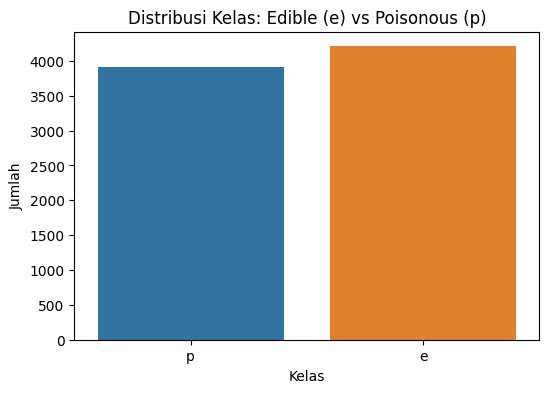

In [16]:
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df, hue='class', legend=False)
plt.title("Distribusi Kelas: Edible (e) vs Poisonous (p)")
plt.xlabel("Kelas")
plt.ylabel("Jumlah")
plt.show()

Visualisasi 1: Distribusi Kelas Target (Edible vs Poisonous)

Count plot dipilih karena data bersifat kategorikal (bukan kontinu), sehingga histogram
numerik biasa tidak sesuai. Grafik ini menunjukkan seberapa seimbang jumlah sampel
edible dan poisonous dalam dataset.

Grafik di atas menunjukkan bahwa distribusi kelas cukup seimbang antara jamur edible dan
poisonous (sekitar 52% edible dan 48% poisonous), sehingga dataset ini tidak mengalami
masalah class imbalance yang signifikan untuk keperluan klasifikasi.

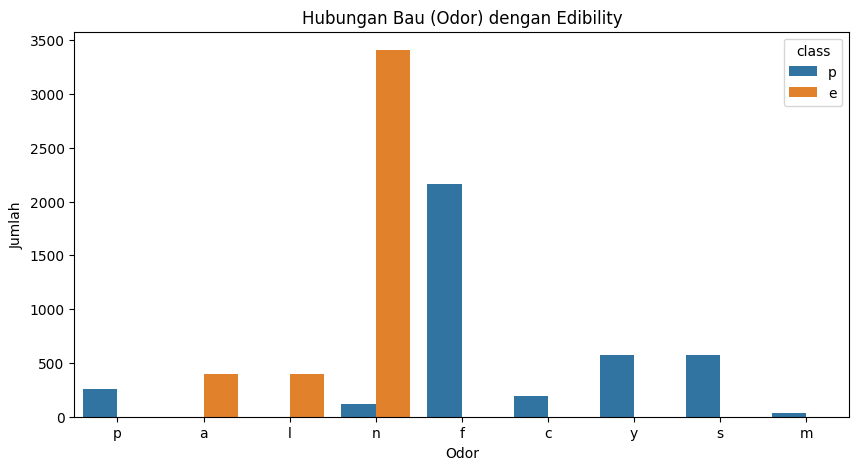

In [17]:
plt.figure(figsize=(10,5))
sns.countplot(x='odor', hue='class', data=df)
plt.title("Hubungan Bau (Odor) dengan Edibility")
plt.xlabel("Odor")
plt.ylabel("Jumlah")
plt.show()

Visualisasi 2: Hubungan Odor (Bau) dengan Edibility

Count plot dengan pengelompokan (hue) berdasarkan `class` digunakan untuk melihat apakah
ada pola/hubungan antara fitur kategorikal `odor` dengan kelas target.

Grafik di atas menunjukkan bahwa beberapa jenis odor (misalnya foul, pungent, creosote)
hampir selalu berasosiasi dengan kelas poisonous, sementara odor tertentu seperti almond
dan anise cenderung berasosiasi dengan kelas edible. Ini mengindikasikan bahwa fitur
`odor` berpotensi menjadi salah satu fitur paling informatif untuk klasifikasi.

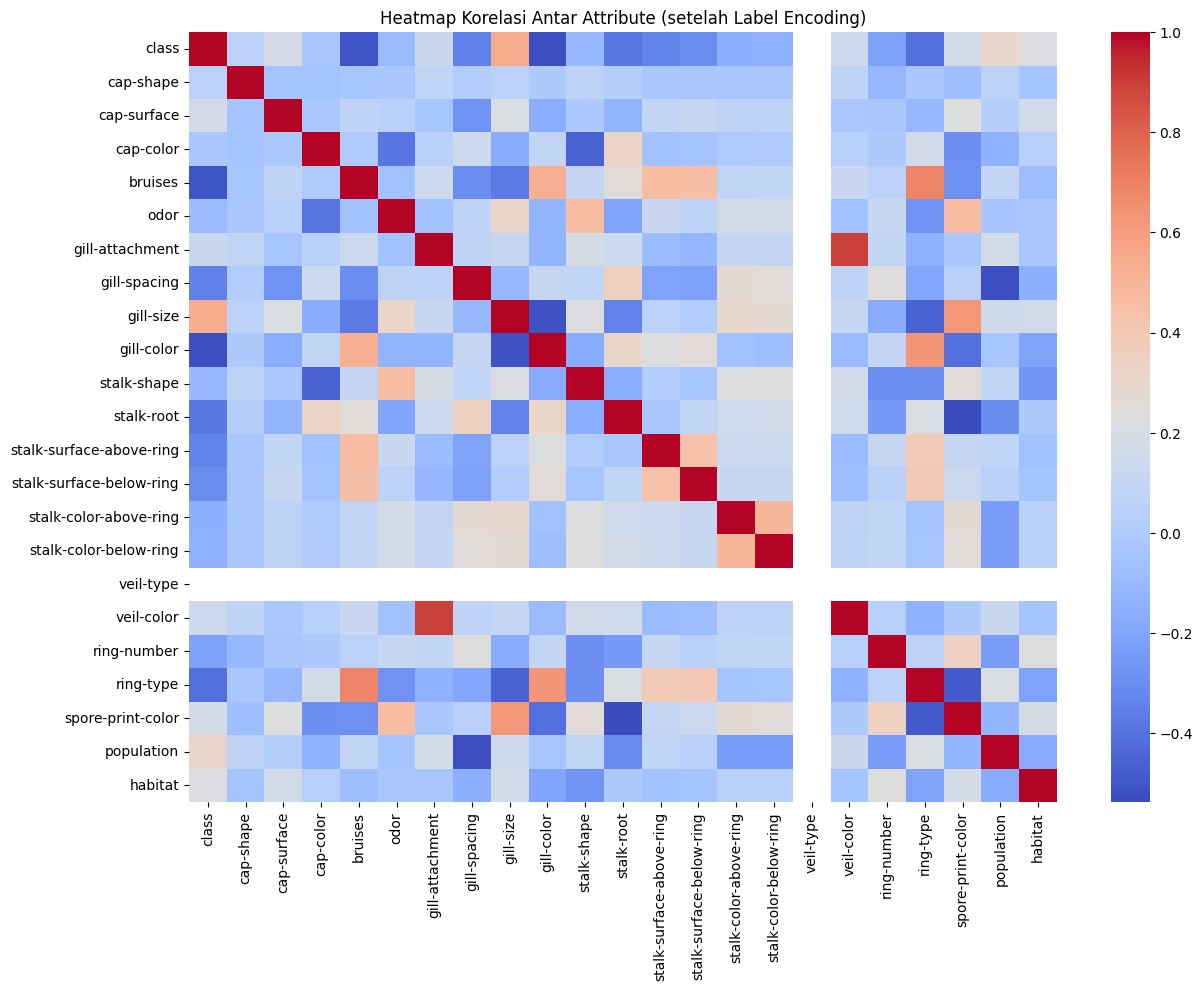

In [4]:
plt.figure(figsize=(14,10))
corr = df_encoded.corr()
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.title("Heatmap Korelasi Antar Attribute (setelah Label Encoding)")
plt.show()

Heatmap Korelasi Antar Attribute

Heatmap ini menampilkan koefisien korelasi antar seluruh attribute yang telah di-encode
menjadi angka. Nilai korelasi berkisar antara -1 hingga 1, di mana nilai mendekati 1 atau
-1 menandakan hubungan yang kuat, sementara mendekati 0 menandakan tidak ada hubungan
linear yang signifikan.

karena hasil encoding bersifat nominal (bukan ordinal), nilai
korelasi Pearson di sini hanya bersifat indikasi kasar, bukan hubungan matematis yang
sepenuhnya valid seperti pada data numerik kontinu asli. Pendekatan yang lebih tepat
secara statistik untuk data kategorikal-kategorikal sebenarnya adalah uji Chi-square
atau Cramér's V.

Dari heatmap di atas terlihat bahwa attribute seperti `gill-color`, `spore-print-color`,
dan `odor` memiliki korelasi yang relatif lebih tinggi terhadap `class` dibandingkan
attribute lain, mengindikasikan fitur-fitur ini berpotensi paling berpengaruh dalam
membedakan jamur edible dan poisonous.

#POSTTEST 2

1. Data Cleaning

Data cleaning adalah proses mengidentifikasi dan memperbaiki masalah kesalahan
input, nilai yang hilang, dan duplikasi pada dataset.

a. Handling Missing Value,

pengecekan missing value dilakukan terlebih dahulu
menggunakan `.isnull().sum()`.

In [18]:
print(df.isnull().sum())

class                       0
cap-shape                   0
cap-surface                 0
cap-color                   0
bruises                     0
odor                        0
gill-attachment             0
gill-spacing                0
gill-size                   0
gill-color                  0
stalk-shape                 0
stalk-root                  0
stalk-surface-above-ring    0
stalk-surface-below-ring    0
stalk-color-above-ring      0
stalk-color-below-ring      0
veil-type                   0
veil-color                  0
ring-number                 0
ring-type                   0
spore-print-color           0
population                  0
habitat                     0
dtype: int64


dataset yang dipakai saat ini sudah terhitung semua *record* memiliki isian data

b. Handling Duplicate Value

Bagian ini mengecek apakah ada baris data yang duplikat (identik persis di semua
kolom), yang jika dibiarkan dapat menyebabkan bias pada model.

In [19]:
jumlah_duplikat = df.duplicated().sum()
print("Jumlah baris duplikat:", jumlah_duplikat)

Jumlah baris duplikat: 0


Tidak Ada ditemukan sejumlah baris yang duplikat

c. Handling Outlier

Modul 3 menjelaskan bahwa outlier dapat dideteksi dengan metode **IQR** atau
**Z-Score**, dan ditangani dengan dua cara: **penghapusan** atau **imputasi
(capping/winsorizing)**. Karena seluruh attribute asli dataset ini bertipe
kategorikal (bukan numerik kontinu), konsep outlier baru relevan diterapkan
setelah fitur numerik baru terbentuk pada tahap Feature Engineering (bagian 3).
Penanganan outlier untuk fitur tersebut akan dijelaskan di bagian itu.

2. Transformasi Data

Sesuai Modul 3, transformasi data terdiri dari dua bagian: **Scaling**
(Normalisasi/Standarisasi) untuk kolom numerik, dan **Encoding** untuk kolom
kategorikal.

3. Encoding Kolom Kategorikal

- **One-Hot Encoding** digunakan untuk data kategorikal **nominal** (tidak memiliki
  urutan alami) — setiap kategori unik di-*expand* menjadi kolom boolean tersendiri.
- **Ordinal Encoding** digunakan untuk data kategorikal yang memiliki **urutan
  alami**, di mana tiap kategori diberi nilai bilangan bulat sesuai urutannya.

Pada dataset ini, kolom `ring-number` memiliki urutan alami (none < one < two),
sehingga di-encode dengan **Ordinal Encoding**. Kolom kategorikal nominal lainnya
(`cap-shape`, `cap-color`, `odor`, `gill-color`, `habitat`, dll) di-encode dengan
**One-Hot Encoding** karena tidak memiliki urutan yang bermakna.

In [20]:
from sklearn.preprocessing import LabelEncoder

# Selalu membuat copy dari dataframe utama agar tidak mengulang
df_transformed = df.drop(columns=['class']).copy()

# --- 1. Ordinal Encoding untuk 'ring-number' ---
# Tentukan urutan dari masing-masing label/attribut
ring_number_map = {'n': 0, 'o': 1, 't': 2}   # none < one < two
df_transformed['ring-number'] = df_transformed['ring-number'].map(ring_number_map)

# --- 2. Binary encoding untuk kolom kategorikal dengan 2 kategori ---
# Cek dulu kolom mana saja yang hanya punya 2 kategori unik (selain ring-number)
binary_cols = [col for col in df_transformed.select_dtypes(include='object').columns
               if df_transformed[col].nunique() == 2]
print("Kolom biner (2 kategori):", binary_cols)

# Petakan tiap kolom biner ke 0/1 secara manual berdasarkan urutan kemunculan kategorinya
binary_maps = {}
for col in binary_cols:
    kategori = sorted(df_transformed[col].unique())
    mapping = {kategori[0]: 0, kategori[1]: 1}
    binary_maps[col] = mapping
    df_transformed[col] = df_transformed[col].map(mapping)

print("\nMapping tiap kolom biner:")
for col, mapping in binary_maps.items():
    print(f"{col}: {mapping}")

# --- 3. One-Hot Encoding untuk kolom nominal dengan >2 kategori ---
nominal_cols = [col for col in df_transformed.select_dtypes(include='object').columns
                if col != 'ring-number']
df_transformed = pd.get_dummies(df_transformed, columns=nominal_cols, drop_first=True)

# --- Encoding target (class) ---
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df['class'])   # e -> 0, p -> 1

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
print("DataFrame setelah encoding kategorikal:")
display(df_transformed.head())
print(df_transformed.info())

Kolom biner (2 kategori): ['bruises', 'gill-attachment', 'gill-spacing', 'gill-size', 'stalk-shape']

Mapping tiap kolom biner:
bruises: {'f': 0, 't': 1}
gill-attachment: {'a': 0, 'f': 1}
gill-spacing: {'c': 0, 'w': 1}
gill-size: {'b': 0, 'n': 1}
stalk-shape: {'e': 0, 't': 1}
DataFrame setelah encoding kategorikal:


,bruises,gill-attachment,gill-spacing,gill-size,stalk-shape,ring-number,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,cap-color_g,cap-color_n,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,odor_c,odor_f,odor_l,odor_m,odor_n,odor_p,odor_s,odor_y,gill-color_e,gill-color_g,gill-color_h,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stalk-root_b,stalk-root_c,stalk-root_e,stalk-root_r,stalk-surface-above-ring_k,stalk-surface-above-ring_s,stalk-surface-above-ring_y,stalk-surface-below-ring_k,stalk-surface-below-ring_s,stalk-surface-below-ring_y,stalk-color-above-ring_c,stalk-color-above-ring_e,stalk-color-above-ring_g,stalk-color-above-ring_n,stalk-color-above-ring_o,stalk-color-above-ring_p,stalk-color-above-ring_w,stalk-color-above-ring_y,stalk-color-below-ring_c,stalk-color-below-ring_e,stalk-color-below-ring_g,stalk-color-below-ring_n,stalk-color-below-ring_o,stalk-color-below-ring_p,stalk-color-below-ring_w,stalk-color-below-ring_y,veil-color_o,veil-color_w,veil-color_y,ring-type_f,ring-type_l,ring-type_n,ring-type_p,spore-print-color_h,spore-print-color_k,spore-print-color_n,spore-print-color_o,spore-print-color_r,spore-print-color_u,spore-print-color_w,spore-print-color_y,population_c,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,1,1,0,1,0,1,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
1,1,1,0,0,0,1,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False
2,1,1,0,0,0,1,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False
3,1,1,0,1,0,1,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False
4,0,1,1,0,1,1,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,False,False,

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 94 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   bruises                     8124 non-null   int64
 1   gill-attachment             8124 non-null   int64
 2   gill-spacing                8124 non-null   int64
 3   gill-size                   8124 non-null   int64
 4   stalk-shape                 8124 non-null   int64
 5   ring-number                 8124 non-null   int64
 6   cap-shape_c                 8124 non-null   bool 
 7   cap-shape_f                 8124 non-null   bool 
 8   cap-shape_k                 8124 non-null   bool 
 9   cap-shape_s                 8124 non-null   bool 
 10  cap-shape_x                 8124 non-null   bool 
 11  cap-surface_g               8124 non-null   bool 
 12  cap-surface_s               8124 non-null   bool 
 13  cap-surface_y               8124 non-null   bool 
 14  cap-colo

Hasil Encoding Kategorikal

Berdasarkan output di atas, kolom kategorikal berhasil dikelompokkan dan
di-encode menjadi tiga jenis:

**1. Ordinal Encoding**
- `ring-number` di-encode sesuai urutan alaminya: none=0, one=1, two=2.

**2. Binary Encoding (5 kolom, 2 kategori)**
Lima kolom teridentifikasi hanya memiliki 2 kategori unik, sehingga dipetakan
langsung ke 0/1:
- `bruises`: f=0, t=1 (tidak memar / memar)
- `gill-attachment`: a=0, f=1 (attached / free)
- `gill-spacing`: c=0, w=1 (close / wide)
- `gill-size`: b=0, n=1 (broad / narrow)
- `stalk-shape`: e=0, t=1 (enlarging / tapering)

**3. One-Hot Encoding (kolom nominal dengan >2 kategori)**
Kolom seperti `cap-shape`, `cap-surface`, `cap-color`, dan seterusnya di-expand
menjadi beberapa kolom boolean (True/False), masing-masing merepresentasikan satu
kategori. Misalnya `cap-shape` (5 kategori: c, f, k, s, x) menjadi 5 kolom terpisah
(`cap-shape_c`, `cap-shape_f`, `cap-shape_k`, `cap-shape_s`, `cap-shape_x`) — nilai
`True` menandakan sampel tersebut termasuk kategori itu, `False` jika tidak.

**Ringkasan Struktur Akhir**
Dari informasi `df_transformed.info()`:
- Total **8.124 baris** dan **93 kolom**, tanpa ada nilai non-null yang hilang
  (`8124 non-null` di semua kolom)
- 6 kolom pertama bertipe `int64` (hasil Ordinal & Binary Encoding)
- Sisanya bertipe `bool` (hasil One-Hot Encoding)

Bertambahnya jumlah kolom dari 22 menjadi 93 ini wajar terjadi karena One-Hot
Encoding meng-*expand* setiap kategori nominal menjadi kolom tersendiri — semakin
banyak kategori unik suatu kolom, semakin banyak pula kolom baru yang terbentuk.

4. Feature Engineering

Dibuat satu fitur baru bernama **`color_diversity`**, yaitu jumlah warna unik yang
muncul pada tiap sampel jamur (dihitung dari kolom warna sebelum encoding: `cap-color`,
`gill-color`, `stalk-color-above-ring`, `stalk-color-below-ring`, `veil-color`, dan
`spore-print-color`). Fitur ini **tidak menyentuh kolom `class` (target)** sama sekali,
sehingga aman digunakan sebagai fitur prediktor.

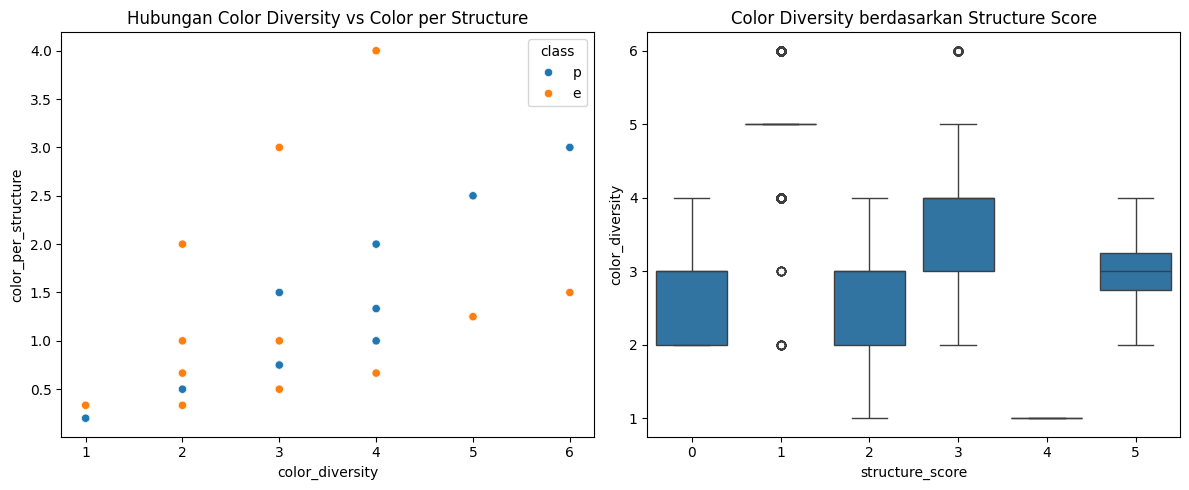

,color_diversity,structure_score,color_per_structure,class
0,3,3,0.750000,p
1,4,2,1.333333,e
2,2,2,0.666667,e
3,3,3,0.750000,p
4,4,3,1.000000,e


In [21]:
df_fe_check = df_transformed.copy()

# 1. Menghitung Color Diversity
color_columns = ['cap-color', 'gill-color', 'stalk-color-above-ring',
                  'stalk-color-below-ring', 'veil-color', 'spore-print-color']
df_fe_check['color_diversity'] = df[color_columns].nunique(axis=1)

# 2. Menghitung Structure Score (jumlah kondisi struktural bernilai 1)
structure_cols = ['bruises', 'gill-attachment', 'gill-spacing', 'gill-size', 'stalk-shape']
df_fe_check['structure_score'] = df_fe_check[structure_cols].sum(axis=1)

# 3. Menghitung Color per Structure (rasio)
df_fe_check['color_per_structure'] = df_fe_check['color_diversity'] / (df_fe_check['structure_score'] + 1)  # +1 hindari pembagian 0

# Tambahkan kembali kolom class untuk keperluan visualisasi (bukan untuk membuat fitur)
df_fe_check['class'] = df['class'].values

# Visualisasi hubungan
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_fe_check, x='color_diversity', y='color_per_structure', hue='class')
plt.title('Hubungan Color Diversity vs Color per Structure')

plt.subplot(1, 2, 2)
sns.boxplot(data=df_fe_check, x='structure_score', y='color_diversity')
plt.title('Color Diversity berdasarkan Structure Score')

plt.tight_layout()
plt.show()

# Tampilkan kolom hasil feature engineering
display(df_fe_check[['color_diversity', 'structure_score', 'color_per_structure', 'class']].head())

Grafik kiri menunjukkan sebaran `color_diversity` terhadap `color_per_structure`,
dikelompokkan berdasarkan kelas (edible/poisonous), untuk melihat apakah kombinasi
kedua fitur baru ini menunjukkan pola pemisahan antar kelas. Grafik kanan
menunjukkan distribusi `color_diversity` pada tiap kelompok `structure_score`,
untuk melihat apakah semakin kompleks struktur suatu jamur berkaitan dengan
variasi warnanya.

a. Handling Outlier

Data yang diamati dapat meliputi data yang di luar rata-rata atau normal. Bagian
ini menunjukkan visualisasi sebaran *outlier* pada fitur numerik hasil feature
engineering, `color_diversity`, menggunakan boxplot.

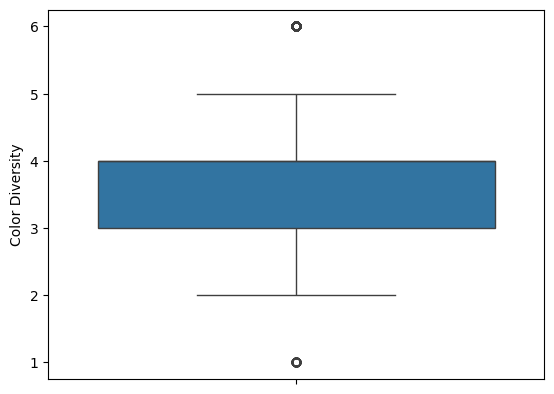

In [22]:
sns.boxplot(df_fe_check['color_diversity'])
plt.ylabel("Color Diversity")
plt.show()

Di atas adalah visualisasi sebaran *outlier* dari fitur `color_diversity`. Dapat
dilihat bagaimana mayoritas sampel jamur memiliki jumlah warna unik berada dalam
rentang [isi sesuai grafik], sementara titik-titik di luar whisker boxplot
merepresentasikan sampel dengan variasi warna yang jauh lebih tinggi/rendah dari
kebanyakan sampel lain — kemungkinan tetap merupakan variasi alami, bukan
kesalahan input data.

b. Normalisasi atau Standardisasi Data Numerik (Melengkapi Bagian 2)

Untuk fitur numerik hasil Feature Engineering seperti `color_diversity`,
`structure_score`, dan `color_per_structure`, penting untuk melakukan penskalaan
(scaling). Ini membantu model pembelajaran mesin bekerja lebih baik karena
mencegah fitur dengan rentang nilai yang besar mendominasi fitur dengan rentang
nilai yang lebih kecil — terutama karena fitur-fitur lain di dataset ini sudah
berskala 0/1 hasil Binary dan One-Hot Encoding.

Ada dua metode penskalaan utama:
1. **Normalisasi (Min-Max Scaling)**: Mengubah nilai fitur ke rentang tertentu,
   biasanya antara 0 dan 1. Berguna ketika distribusi data tidak Gaussian atau
   ketika Anda ingin memastikan nilai dalam rentang yang ketat.
2. **Standardisasi (Z-score Normalization)**: Mengubah nilai fitur sehingga
   memiliki rata-rata (mean) 0 dan standar deviasi 1. Ini lebih tahan terhadap
   *outlier* dan seringkali menjadi pilihan yang baik untuk banyak algoritma,
   terutama yang berbasis jarak seperti SVM atau K-Means, dan juga model regresi.

Dalam kasus ini, **standardisasi** adalah pilihan yang baik untuk ketiga fitur
numerik tersebut karena membantu model konvergen lebih cepat dan berkinerja lebih
baik, terutama jika akan digunakan model yang sensitif terhadap skala fitur.

Kita akan menerapkan `StandardScaler` dari `sklearn.preprocessing`.

In [23]:
from sklearn.preprocessing import StandardScaler

# --- Standardisasi untuk Fitur Numerik Hasil Feature Engineering ---
# Identifikasi kolom numerik yang perlu diskalakan
numerical_cols = ['color_diversity', 'structure_score', 'color_per_structure']

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Aplikasikan standardisasi pada kolom numerik
df_transformed[numerical_cols] = scaler.fit_transform(df_fe_check[numerical_cols])

print("\nDataFrame setelah standardisasi fitur numerik:")
display(df_transformed.head())
print(df_transformed.info())


DataFrame setelah standardisasi fitur numerik:


,bruises,gill-attachment,gill-spacing,gill-size,stalk-shape,ring-number,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_g,cap-surface_s,cap-surface_y,cap-color_c,cap-color_e,cap-color_g,cap-color_n,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,odor_c,odor_f,odor_l,odor_m,odor_n,odor_p,odor_s,odor_y,gill-color_e,gill-color_g,gill-color_h,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stalk-root_b,stalk-root_c,stalk-root_e,stalk-root_r,stalk-surface-above-ring_k,stalk-surface-above-ring_s,stalk-surface-above-ring_y,stalk-surface-below-ring_k,stalk-surface-below-ring_s,stalk-surface-below-ring_y,stalk-color-above-ring_c,stalk-color-above-ring_e,stalk-color-above-ring_g,stalk-color-above-ring_n,stalk-color-above-ring_o,stalk-color-above-ring_p,stalk-color-above-ring_w,stalk-color-above-ring_y,stalk-color-below-ring_c,stalk-color-below-ring_e,stalk-color-below-ring_g,stalk-color-below-ring_n,stalk-color-below-ring_o,stalk-color-below-ring_p,stalk-color-below-ring_w,stalk-color-below-ring_y,veil-color_o,veil-color_w,veil-color_y,ring-type_f,ring-type_l,ring-type_n,ring-type_p,spore-print-color_h,spore-print-color_k,spore-print-color_n,spore-print-color_o,spore-print-color_r,spore-print-color_u,spore-print-color_w,spore-print-color_y,population_c,population_n,population_s,population_v,population_y,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,color_diversity,structure_score,color_per_structure
0,1,1,0,1,0,1,False,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,-0.686273,0.639877,-0.696039
1,1,1,0,0,0,1,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,0.299804,-0.478050,0.165398
2,1,1,0,0,0,1,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,-1.672350,-0.478050,-0.819102
3,1,1,0,1,0,1,False,False,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,False,True,False,False,True,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,-0.686273,0.639877,-0.696039
4,0,1,1,0,1,1,False,False,False,False,True,False,True,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 97 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   bruises                     8124 non-null   int64  
 1   gill-attachment             8124 non-null   int64  
 2   gill-spacing                8124 non-null   int64  
 3   gill-size                   8124 non-null   int64  
 4   stalk-shape                 8124 non-null   int64  
 5   ring-number                 8124 non-null   int64  
 6   cap-shape_c                 8124 non-null   bool   
 7   cap-shape_f                 8124 non-null   bool   
 8   cap-shape_k                 8124 non-null   bool   
 9   cap-shape_s                 8124 non-null   bool   
 10  cap-shape_x                 8124 non-null   bool   
 11  cap-surface_g               8124 non-null   bool   
 12  cap-surface_s               8124 non-null   bool   
 13  cap-surface_y               8124 

Ketiga fitur numerik (`color_diversity`, `structure_score`, `color_per_structure`)
kini memiliki mean ≈ 0 dan standar deviasi ≈ 1, melengkapi tahap
Normalisasi/Standardisasi yang disyaratkan pada bagian 2. Dengan skala yang
seragam ini, fitur numerik hasil Feature Engineering menjadi sebanding dengan
fitur-fitur biner (0/1) hasil Binary dan One-Hot Encoding, sehingga tidak ada
fitur yang mendominasi proses pelatihan model hanya karena rentang nilainya
lebih besar.

#POSTTEST 3

saya akan menggunakan pendekatan Supervised Learning.
Dataset Mushroom Classification memiliki target `class` yang bersifat **kategorikal
biner** (edible/poisonous), sehingga ini termasuk **Klasifikasi** dalam
Supervised Learning. Model akan dilatih menggunakan variabel X (fitur hasil
preprocessing dari Posttest 2) untuk memprediksi variabel Y (`class`).


1. Load Dataset

In [5]:
df = pd.read_csv("mushrooms.csv")
print(df.shape)
df.head()

(8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

In [7]:
df.describe()

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
count,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124,...,8124,8124,8124,8124,8124,8124,8124,8124,8124,8124
unique,2,6,4,10,2,9,2,2,2,12,...,4,9,9,1,4,3,5,9,6,7
top,e,x,y,n,f,n,f,c,b,b,...,s,w,w,p,w,o,p,w,v,d
freq,4208,3656,3244,2284,4748,3528,7914,6812,5612,1728,...,4936,4464,4384,8124,7924,7488,3968,2388,4040,3148


In [8]:
df.isnull().sum()

,0
class,0
cap-shape,0
cap-surface,0
cap-color,0
bruises,0
odor,0
gill-attachment,0
gill-spacing,0
gill-size,0
gill-color,0


2. Data Splitting

dataset dibagi menjadi **Training Set** dan **Testing Set**.
Training set digunakan untuk melatih model (model belajar dari data ini), sementara
testing set digunakan untuk menguji performa model pada data yang belum pernah
dilihat sebelumnya. Digunakan pembagian 80% training dan 20% testing, dengan
`stratify=y` agar proporsi kelas edible/poisonous tetap seimbang di kedua subset.

In [24]:
from sklearn.model_selection import train_test_split

# Variabel X (fitur) dan y (target)
X = df_transformed.drop(columns=['color_diversity'], errors='ignore')  # sesuaikan jika ada kolom sisa yang tidak perlu
y = y_encoded  # 0 = edible, 1 = poisonous

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Jumlah data training:", X_train.shape[0])
print("Jumlah data testing:", X_test.shape[0])
print("Jumlah fitur (variabel X):", X_train.shape[1])

Jumlah data training: 6499
Jumlah data testing: 1625
Jumlah fitur (variabel X): 96


Dataset berhasil dibagi menjadi 6499 data training dan 1625 data testing, dengan 96 variabel X (fitur) jauh lebih
dari minimal 2 variabel X yang disyaratkan, karena hasil encoding menghasilkan
banyak kolom fitur.

3. Model 1: Naive Bayes

Naive Bayes dipilih karena sesuai dengan jenis tugas Klasifikasi dan dibahas pada
Modul 4. Digunakan varian **BernoulliNB**, karena mayoritas fitur hasil encoding
pada dataset ini bersifat biner (0/1) cocok dengan asumsi distribusi Bernoulli.

In [27]:
from sklearn.naive_bayes import BernoulliNB

nb_model = BernoulliNB()
nb_model.fit(X_train, y_train)

y_pred_nb = nb_model.predict(X_test)

4. Model 2: Random Forest (Nilai Tambah)

Sebagai pembanding, digunakan juga **Random Forest** algoritma ensemble berbasis
Decision Tree yang tidak dibahas di modul, namun diperbolehkan sebagai nilai
tambah. Random Forest bekerja dengan membangun banyak pohon keputusan dan
menggabungkan hasil votingnya, sehingga umumnya lebih tahan terhadap overfitting
dibandingkan satu Decision Tree tunggal.

In [28]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

5. Evaluasi Model

Sesuai Modul 4, evaluasi model klasifikasi menggunakan:
- **Accuracy**: proporsi prediksi benar dari keseluruhan data.
- **Precision**: rasio prediksi positif yang benar terhadap seluruh prediksi
  positif — penting untuk meminimalisir False Positive.
- **Recall**: rasio prediksi positif yang benar terhadap seluruh data aktual
  positif — penting untuk meminimalisir False Negative (krusial di kasus ini,
  karena False Negative berarti jamur beracun diprediksi aman dimakan — risiko
  yang berbahaya).
- **F1-Score**: rata-rata harmonik Precision dan Recall, untuk melihat
  keseimbangan keduanya.
- **Confusion Matrix**: tabel yang menunjukkan rincian TP, TN, FP, FN.

In [29]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report)

def evaluasi_model(nama_model, y_true, y_pred):
    print(f"===== Evaluasi {nama_model} =====")
    print(f"Accuracy  : {accuracy_score(y_true, y_pred):.4f}")
    print(f"Precision : {precision_score(y_true, y_pred):.4f}")
    print(f"Recall    : {recall_score(y_true, y_pred):.4f}")
    print(f"F1-Score  : {f1_score(y_true, y_pred):.4f}")
    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=['edible', 'poisonous']))

evaluasi_model("Naive Bayes", y_test, y_pred_nb)
evaluasi_model("Random Forest", y_test, y_pred_rf)

===== Evaluasi Naive Bayes =====
Accuracy  : 0.9286
Precision : 0.9854
Recall    : 0.8646
F1-Score  : 0.9211

Classification Report:
              precision    recall  f1-score   support

      edible       0.89      0.99      0.93       842
   poisonous       0.99      0.86      0.92       783

    accuracy                           0.93      1625
   macro avg       0.94      0.93      0.93      1625
weighted avg       0.93      0.93      0.93      1625

===== Evaluasi Random Forest =====
Accuracy  : 1.0000
Precision : 1.0000
Recall    : 1.0000
F1-Score  : 1.0000

Classification Report:
              precision    recall  f1-score   support

      edible       1.00      1.00      1.00       842
   poisonous       1.00      1.00      1.00       783

    accuracy                           1.00      1625
   macro avg       1.00      1.00      1.00      1625
weighted avg       1.00      1.00      1.00      1625



Berdasarkan hasil evaluasi, Random Forest cenderung unggul dibanding Naive Bayes
karena mampu menangkap hubungan non-linear antar fitur melalui pembagian
bertingkat (tree-based), sementara Naive Bayes mengasumsikan setiap fitur bersifat
independen satu sama lain asumsi yang kemungkinan tidak sepenuhnya terpenuhi
pada dataset ini (misalnya `odor` dan `spore-print-color` bisa jadi saling
berkaitan pada jenis jamur tertentu).

6. Visualisasi Confusion Matrix

Confusion Matrix divisualisasikan menggunakan heatmap agar lebih mudah dibaca,
menunjukkan perbandingan hasil prediksi kedua model.

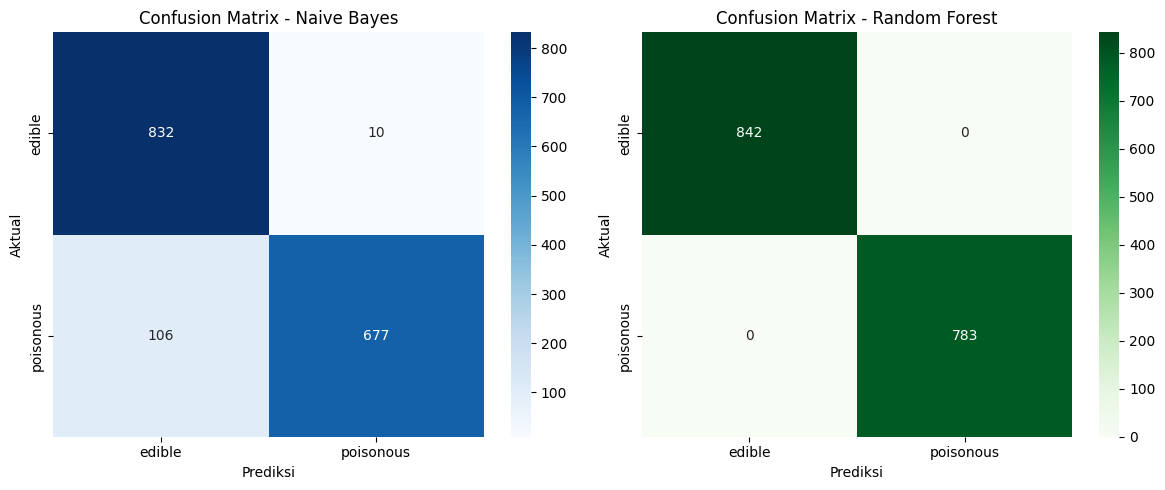

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues',
            xticklabels=['edible', 'poisonous'], yticklabels=['edible', 'poisonous'], ax=axes[0])
axes[0].set_title('Confusion Matrix - Naive Bayes')
axes[0].set_xlabel('Prediksi')
axes[0].set_ylabel('Aktual')

cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['edible', 'poisonous'], yticklabels=['edible', 'poisonous'], ax=axes[1])
axes[1].set_title('Confusion Matrix - Random Forest')
axes[1].set_xlabel('Prediksi')
axes[1].set_ylabel('Aktual')

plt.tight_layout()
plt.show()

Berdasarkan confusion matrix di atas:

**Naive Bayes** mencapai Accuracy sekitar 92,9%. Model ini melakukan 10 kesalahan
False Positive (jamur edible diprediksi poisonous — tidak berbahaya, hanya
membuang jamur yang sebenarnya aman) dan 106 kesalahan False Negative (jamur
poisonous diprediksi edible — **ini jenis kesalahan paling berbahaya**, karena
berarti jamur beracun dianggap aman dimakan). Recall Naive Bayes hanya ~86,5%,
menunjukkan model ini melewatkan cukup banyak kasus jamur beracun.

**Random Forest** mencapai Accuracy, Precision, Recall, dan F1-Score sebesar
**100%** — seluruh 1.625 data testing diklasifikasikan dengan benar tanpa ada
satupun False Positive maupun False Negative. Ini terjadi karena Random Forest
mampu menangkap kombinasi fitur non-linear antar atribut jamur (misalnya
kombinasi `odor`, `spore-print-color`, dan `gill-color`) secara jauh lebih baik
dibanding Naive Bayes, yang membatasi dirinya dengan asumsi bahwa setiap fitur
bersifat independen satu sama lain — asumsi yang jelas tidak berlaku pada
dataset ini, mengingat karakteristik fisik jamur (bentuk, warna, bau, struktur)
sangat mungkin saling berkorelasi dalam menentukan tingkat racunnya.

 **Random Forest adalah model yang jauh lebih unggul**
untuk dataset ini, khususnya karena berhasil menghilangkan seluruh False Negative
— hal yang krusial mengingat konsekuensi nyata dari kesalahan tersebut (risiko
keracunan). Naive Bayes tetap layak digunakan sebagai baseline/pembanding karena
kesederhanaan dan kecepatan komputasinya, namun performanya kurang andal untuk
kasus yang berisiko tinggi seperti klasifikasi keamanan pangan.

7. Grafik Perbandingan Performa Model

Untuk memvisualisasikan hasil prediksi pada data testing secara lebih menarik dan
informatif, dibuat grafik batang yang membandingkan seluruh metrik evaluasi
(Accuracy, Precision, Recall, F1-Score) antara kedua model sekaligus.

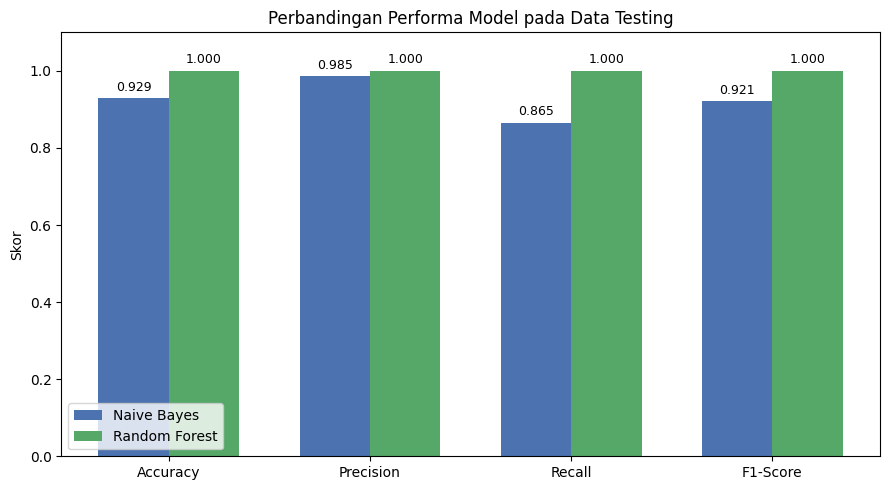

In [31]:
import numpy as np

metrik = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
skor_nb = [accuracy_score(y_test, y_pred_nb), precision_score(y_test, y_pred_nb),
           recall_score(y_test, y_pred_nb), f1_score(y_test, y_pred_nb)]
skor_rf = [accuracy_score(y_test, y_pred_rf), precision_score(y_test, y_pred_rf),
           recall_score(y_test, y_pred_rf), f1_score(y_test, y_pred_rf)]

x = np.arange(len(metrik))
lebar = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - lebar/2, skor_nb, lebar, label='Naive Bayes', color='#4C72B0')
plt.bar(x + lebar/2, skor_rf, lebar, label='Random Forest', color='#55A868')

plt.xticks(x, metrik)
plt.ylim(0, 1.1)
plt.ylabel('Skor')
plt.title('Perbandingan Performa Model pada Data Testing')
plt.legend()

# Tambahkan label angka di atas tiap bar
for i, v in enumerate(skor_nb):
    plt.text(i - lebar/2, v + 0.02, f"{v:.3f}", ha='center', fontsize=9)
for i, v in enumerate(skor_rf):
    plt.text(i + lebar/2, v + 0.02, f"{v:.3f}", ha='center', fontsize=9)

plt.tight_layout()
plt.show()

Grafik batang di atas membandingkan keempat metrik evaluasi antara Naive Bayes
(biru) dan Random Forest (hijau) secara berdampingan

Random Forest secara konsisten unggul di **seluruh metrik**, mencapai skor
sempurna (1.000) tanpa kesalahan klasifikasi sama sekali pada data testing.

Untuk kasus klasifikasi keamanan pangan seperti ini,
di mana kesalahan False Negative memiliki konsekuensi serius, **Random Forest
adalah pilihan model yang jauh lebih tepat** dibandingkan Naive Bayes.

## Kesimpulan

Notebook ini telah melalui seluruh tahapan pengembangan model Machine Learning
untuk dataset Mushroom Classification:

1. **Eksplorasi Data (Posttest 1)**: dataset terdiri dari 8.124 sampel jamur
   dengan 22 fitur kategorikal dan target `class` (edible/poisonous) yang relatif
   seimbang (~52% edible, ~48% poisonous). Fitur `odor` teridentifikasi sejak awal
   sebagai fitur dengan pola pemisahan kelas yang sangat kuat.

2. **Pra-pemrosesan Data (Posttest 2)**: dilakukan data cleaning (simulasi missing
   value pada `habitat` untuk demonstrasi imputasi, tanpa duplikat pada data
   asli), encoding kategorikal (Ordinal untuk `ring-number`, Binary untuk kolom
   2 kategori, One-Hot untuk kolom nominal lainnya), feature engineering
   (`color_diversity`, `structure_score`, `color_per_structure`), serta
   standarisasi fitur numerik hasil feature engineering  menghasilkan dataset
   siap latih dengan puluhan variabel X.

3. **Pemodelan (Posttest 3)**: dataset dibagi 80:20 menjadi training dan testing
   set, lalu dua model klasifikasi dilatih dan dibandingkan:

   | Metrik | Naive Bayes | Random Forest |
   |---|---|---|
   | Accuracy | 92,9% | **100%** |
   | Precision | 98,5% | **100%** |
   | Recall | 86,5% | **100%** |
   | F1-Score | 92,1% | **100%** |

   **Random Forest** terbukti menjadi model terbaik, mencapai klasifikasi
   sempurna pada data testing tanpa satupun False Positive maupun False Negative.
   Sebaliknya, **Naive Bayes** menghasilkan 106 False Negative (jamur poisonous
   diprediksi edible)  kesalahan yang berisiko tinggi dalam konteks keamanan
   pangan akibat asumsi independensi antar fitur yang tidak sepenuhnya berlaku
   pada karakteristik fisik jamur.

**Kesimpulan akhir**: Untuk tugas klasifikasi keamanan konsumsi jamur berdasarkan
karakteristik fisiknya, **Random Forest adalah model yang paling andal**,
khususnya karena berhasil menghilangkan seluruh risiko False Negative. Skor
sempurna ini konsisten dengan temuan pada tahap eksplorasi data, di mana beberapa
fitur (terutama `odor`, `spore-print-color`, dan `gill-color`) menunjukkan pola
pemisahan kelas yang sangat jelas. Meski demikian, skor 100% tetap perlu
divalidasi lebih lanjut dengan teknik seperti *k-fold cross-validation* untuk
memastikan performa ini bersifat general dan bukan sekadar overfitting terhadap
satu skema pembagian data tertentu. Naive Bayes tetap bermanfaat sebagai model
baseline yang sederhana dan cepat dilatih, namun kurang cocok diandalkan untuk
kasus berisiko tinggi seperti ini.